# CHAI Instrument Walkthrough

This notebook demonstrates how to use the AtLAST Sensitivity Calculator with the CHAI (CCAT Heterodyne Array Instrument) instrument. CHAI is a wideband heterodyne receiver designed for the CCAT telescope.

## CHAI Specifications

- **Frequency Range**: 460 - 500, 780 - 820 GHz
- **Receiver Temperature**: 
\begin{equation} 
T_{rx} = \left\{ \begin{array}{rcl}
            100\,\textrm{K} & \textrm{for} & 460<\nu<500\,\textrm{GHz} \\ 
            200\,\textrm{K} & \textrm{for} & 780<\nu<820\,\textrm{GHz} 
            \end{array}\right. \nonumber
            \end{equation}
- **Type**: Heterodyne receiver
- **Purpose**: High-frequency spectroscopic observations
- **Instrument Webpage**: [CHAI webpage](https://www.ccatobservatory.org/chai/)
- **Instrument Reference**: [Barrueto et al. 2023](https://articles.adsabs.harvard.edu/pdf/2023pcsf.conf..346B)

This walkthrough will guide you through:
1. Setting up the calculator with CHAI parameters
2. Demonstration of the typical calculator usage
3. Ensuring correct instrument selection
4. Visualising frequency coverage
5. Evaluating atmospheric conditions
6. Calculating system performance metrics


## Setup and Imports

First, we import the necessary modules and initialise the calculator.

In [3]:
# Import utilities
import numpy as np
import astropy.units as u

# Import Sensitivity Calculator
from atlast_sc.calculator import Calculator

# Import Plotting routines
import matplotlib.pyplot as plt
# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## Quick Demonstration of the Calculator Usage

Here we show a quick demonstration of how the typical user will interact with the calculator in the CHAI parameter space.

### Initialise the Calculator with CHAI Parameters

We'll initialise the calculator with observation parameters that fall within CHAI's frequency range and spectral resolution capabilities. The native spectral resolution of CHAI is 64 kHz, so for lower spectral resolutions, we assume smoothing.

By setting CHAI appropriate observing frequency and spectral channel bandwidth, the AtLAST sensitivity calculator will automatically select the appropriate instrument based on the observing frequency and single channel bandwidth.

In [19]:
# Create calculator instance
calculator = Calculator()

# Set observation parameters for CHAI
calculator.user_input.obs_freq = 480.0 * u.GHz  # within CHAI's range (460-500 or 780-820 GHz)
calculator.user_input.weather = 25.0  # percentile water vapour (see documentation for conversion to mm)
calculator.user_input.bandwidth = 100.0 * u.kHz  # near the spectral resolution limit of the instrument (64 kHz)
calculator.user_input.t_int = 30.0 * u.min  # on source time only, no calibration time added

Instrument has been changed from Default to Chai.


The output above shows that, given the inputs, the code has already chosen CHAI as a suitable instrument for this calculation. CHAI is a single polarisation instrument, therefore we also need to set $n_\mathrm{pol}=1$ when using it.

In [20]:
# Restrict the polarisations to 1
calculator.user_input.n_pol = 1

To show the full list of parameters set for the initial calculations, we can ask the calculator to 'show' the full list of inputs available. Those not explicitly set above are passed their default settings.

In [21]:
print(f"Calculator initialised with the following parameters:")
calculator.user_input.show()


Calculator initialised with the following parameters:
bandwidth: 100.0 kHz
elevation: 45.0 deg
n_pol: 1.0
obs_freq: 480.0 GHz
sensitivity: 3.0 mJy
t_int: 30.0 min
weather: 25.0


### Calculating the Sensitivity or Observing Time for an Observation

Given these inputs we can then calculate the sensitivity reached in a 30 minute observation at an observing frequency of 480 GHz and spectral resolution of 100 kHz.

In [22]:
sens = calculator.calculate_sensitivity()
print(f'RMS sensitivity per channel: {sens}')

RMS sensitivity per channel: 177.0938946374835 mJy


Alternatively we can calculate the on source observing time to reach a given sensitivity.

In [24]:
calculator.user_input.sensitivity = 63*u.mJy
obs_time = calculator.calculate_t_integration()
print(f'On source observing time required: {obs_time}')

On source observing time required: 3.950900417973306 h


This is all that is needed for the typical user. The following steps of this notebook demonstrate the validation of the instrument and then the details of the sensitivity calculation for SEPIA.

## Ensuring Correct Instrument Selection

The calculator provides validation to ensure that your observing parameters (frequency and bandwidth) are compatible with the chosen instrument. This validation ensures your calculations are internally consistent with your expectations. If the parameters don't match, it raises an `InstrumentNotApplicableException` and suggests ways of setting a valid calculation.

### Why This Validation is Important

This validation prevents you from accidentally using an instrument with parameters outside its valid ranges, which would lead to incorrect sensitivity calculations. The error message helps you either:
- Adjust your parameters to fit the desired instrument, or
- Choose an instrument that matches your observing requirements

### Checking the Selected Instrument

Let's verify which instrument was automatically selected for our observation frequency:

In [25]:
# Check which instrument was automatically selected
print(f"Automatically selected instrument: {calculator.chosen_instrument}")

Automatically selected instrument: Chai


### Demonstrating Instrument Validation

Let's demonstrate how the instrument validation works. We'll first try to set CHAI with incompatible parameters to see the validation in action, then show the correct approach.

In [26]:
# First, let's temporarily set incompatible parameters (bandwidth too large for CHAI)
calculator.user_input.bandwidth = 8.0 * u.GHz  # outside CHAI's range (max 4 GHz)

# This will raise an exception because our bandwidth doesn't fit CHAI's ranges
try:
    calculator.chosen_instrument = 'CHAI'
    print("Instrument set successfully")
except Exception as e:
    print(f"Cannot set to CHAI: {type(e).__name__}")
    print(f"Reason: {str(e)}")


Instrument has been changed from Chai to Default.
Cannot set to CHAI: InstrumentNotApplicableException
Reason: Specified observing frequency and/or bandwidth values do not correspond to the chosen instrument 'Chai' ranges. Change the observing frequency and/or bandwidth values to use this instrument or choose another instrument. The set of parameters provided corresponds to other instrument/s, e.g. 'Default'. To check the frequency and bandwidth ranges of the installed instruments type calculator.list_instruments().


Knowing that the setup is wrong, the above error statement is expected. Now lets reset the observing bandwidth to something that is achievable with CHAI, and then show that that change has been applied.

In [27]:
# Reset to compatible bandwidth
calculator.user_input.bandwidth = 100.0 * u.kHz  # GHz - back within CHAI's range
calculator.user_input.show()
print(f"Calculations will now be performed using: {calculator.chosen_instrument}")

Instrument has been changed from Default to Chai.
bandwidth: 100.0 kHz
elevation: 45.0 deg
n_pol: 1.0
obs_freq: 480.0 GHz
sensitivity: 63.0 mJy
t_int: 30.0 min
weather: 25.0
Calculations will now be performed using: Chai


## Visualise the inputs to the sensitivity calculation as a function of Frequency

Let's visualise how various parameters change as a function of frequency across the CHAI bands. Because CHAI has a low frequency and high frequency array, lets setup an array of frequencies that combines these two ranges for derivations through the notebook

In [28]:
# Create a frequency array spanning CHAI's specific frequency ranges for plotting
nf = 150    # number of frequencies per array
freq1 = np.linspace(460, 500, nf)  # frequencies of the Low Frequency Array
freq2 = np.linspace(780, 820, nf)  # frequencies of the High Frequency Array
frequencies = np.concatenate([freq1, freq2])


Because the calculator re-calculates on each parameter change, and there are a lot of calculations being done in this notebook, there is a single loop here which calculates all of the parameters we're exploring in the rest of the notebook. This includes:

* Atmospheric transmission (transmission)
* Receiver temperature (T_rx)
* System temperature (T_sys)
* Ambient temperature (T_amb)
* System Equivalent Flux Density (SEFD)
* Sensitivity

Expect this loop to take around 5 minutes.

In [29]:

# expose the CHAI instrument module in order to pull our the temperatures used in the calculations
chai_instrument = calculator._param_setup.chosen_instrument

# initialise empty lists to store the calculated parameters
transmission = []
t_rx_values = []
t_sky_contribution = []
t_amb_contribution = []
sefd_values = []
sensitivity = []


# looping over the frequency ranges covered by CHAI
for freq in frequencies:
    # Set the observing frequency for this loop iteration, which triggers a re-calculation
    calculator.user_input.obs_freq = freq * u.GHz

    # extract atmospheric transmission from the calculator, and add it to the list
    transmission.append(calculator.derived_parameters.transmittance)

    # extract receiver temperature from the calculator, and add it to the list
    t_rx = chai_instrument.calculate_receiver_temp(calculator.user_input.obs_freq)
    t_rx_values.append(t_rx)

    # extract sky and ambient temperatures from the calculator, and add them to the lists
    t_sky_contribution.append(calculator.derived_parameters.T_sky.value)
    t_amb_contribution.append(calculator.telescope_and_environment.T_amb.value)

    # extract SEFD from the calculator, and add it to the list
    sefd_values.append(calculator.derived_parameters.sefd.to("Jy").value)

    # extract sensitivity from the calculator, and add it to the list
    sensitivity.append(calculator.calculate_sensitivity())



With all of those parameters derived, the following describes how they're used in the calculator, and we plot their values over the operational frequency ranges of CHAI.

### Atmospheric Transmission

To show how atmospheric transmission varies, we plot the transmission as a function of frequency across the CHAI operational frequency ranges. This is important for understanding how the sensitivity of the instrument changes with frequency.  The atmospheric transmission is calculated using the am code.

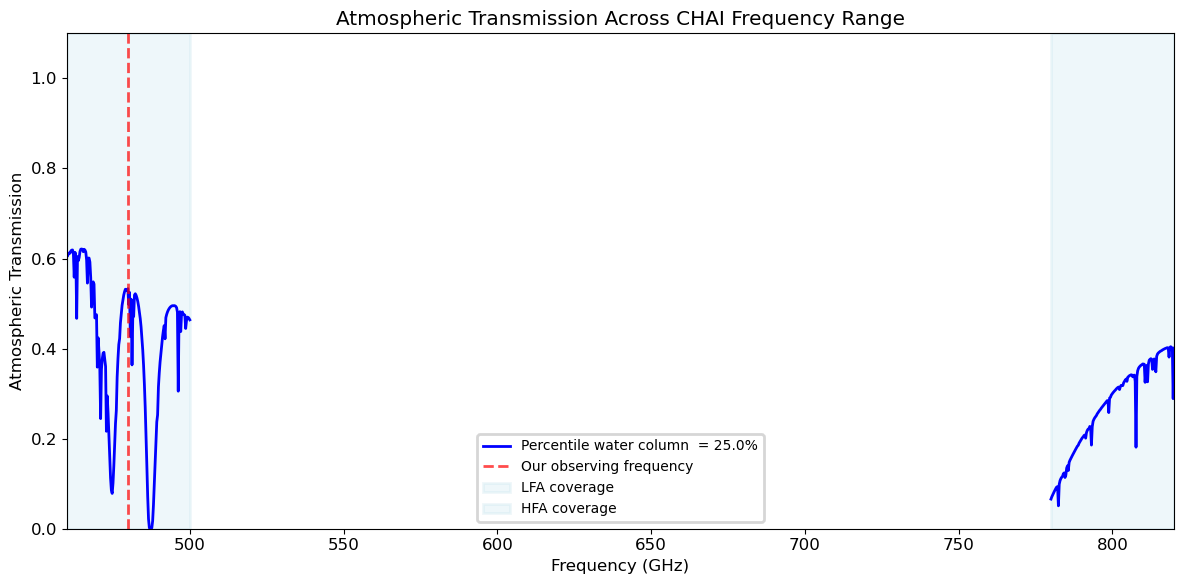

In [30]:

# Reset to our primary observing frequency
calculator.user_input.obs_freq = 480.0*u.GHz

# Plot
fig, ax = plt.subplots()

# plot atmospheric transmission over the CHAI operational frequency ranges
ax.plot(freq1, transmission[:nf], 'b-', linewidth=2, label=f'Percentile water column  = {calculator.user_input.weather}%')
ax.plot(freq2, transmission[nf:], 'b-', linewidth=2)
# draw a vertical line at our observing frequency (dashed)
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
#draw boxes to highlight the operational frequencies of the CHAI receiver
ax.axvspan(freq1[0],freq1[-1], color='lightblue', alpha=0.2, label='LFA coverage')
ax.axvspan(freq2[0],freq2[-1], color='lightblue', alpha=0.2, label='HFA coverage')

# label the plot
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Atmospheric Transmission')
ax.set_title('Atmospheric Transmission Across CHAI Frequency Range')
ax.legend()
ax.set_ylim([0, 1.1])
plt.tight_layout()
plt.show()



## Receiver Temperature Calculation

CHAI's receiver temperature changes between the two arrays, as shown below.

* T_rx = 100 K for the low frequency array (460-500 GHz)
* T_rx = 200 K for the high frequency array (780-820 GHz)

We can show how the receiver temperatures are set for the two arrays, which is important for understanding the sensitivity of the instrument. The receiver temperature is a key factor in determining the instrument's sensitivity, as it affects the amount of noise that is added to the signal.

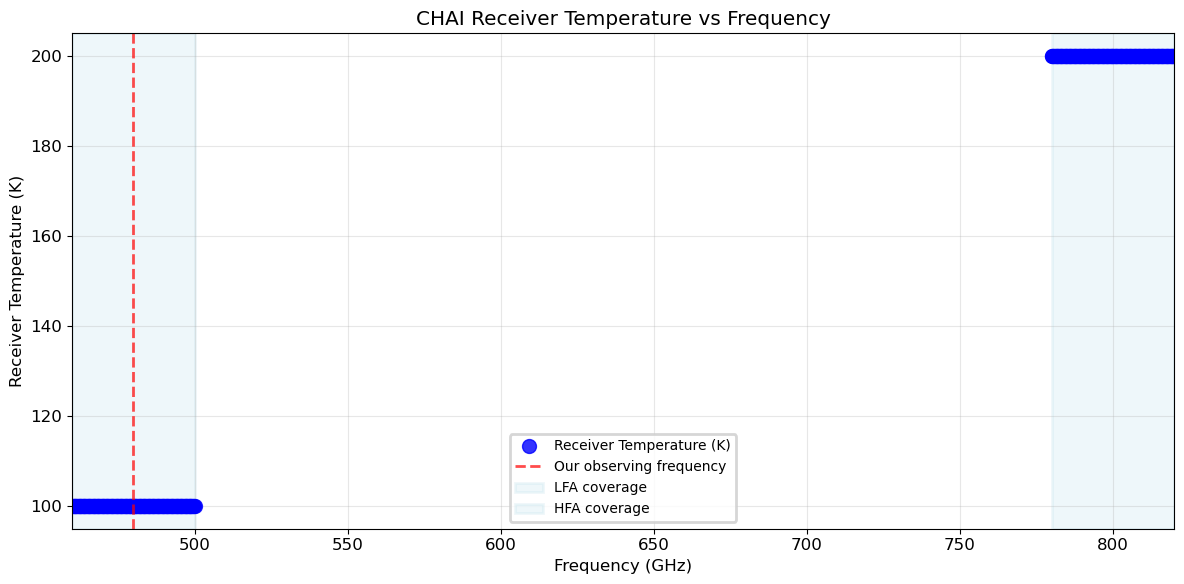

In [31]:
# Filter out None values from t_rx_values for plotting
valid_data = [(freq, t_rx) for freq, t_rx in zip(frequencies, t_rx_values) if t_rx is not None]
valid_frequencies, valid_t_rx = zip(*valid_data) if valid_data else ([], [])

# Plot the receiver temperatures.
fig, ax = plt.subplots()
ax.plot(valid_frequencies, [t.value for t in t_rx_values], 'o',label = 'Receiver Temperature (K)', color='b', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
ax.axvspan(freq1[0],freq1[-1], color='lightblue', alpha=0.2, label='LFA coverage')
ax.axvspan(freq2[0],freq2[-1], color='lightblue', alpha=0.2, label='HFA coverage')
ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Receiver Temperature (K)')
ax.set_title('CHAI Receiver Temperature vs Frequency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## System Temperature Calculation

The instrument module calculates the system temperature using the following equation:

$$    T_{sys} = \frac{1}{\eta_{eff} \mathfrak{t}} \times [T_{rx} + (\eta_{eff} T_{sky}) + (1-\eta_{eff}) O(\nu, T_\mathrm{amb})]$$


It includes contributions from:
- Receiver temperature (T_rx)
- Sky temperature (T_sky)
- Ambient Temperature (T_amb)

Here, $O(\nu, T)$ is the conversion from a thermodynamic temperature to a Rayleigh-Jeans brightness temperature that is applied to the ambient temperature for consistency with the receiver temperature and sky temperature

\begin{equation}
    O(\nu, T) = T \frac{h\nu/kT}{\exp(h\nu/kT)-1}.  \nonumber
\end{equation}
where $h$ and $k$ are the Planck and Boltzmann constants respectively.

Below, we show plots of the three noise temperature equivalent components of the system temperature: sky, ambient and receiver as a function of frequency.

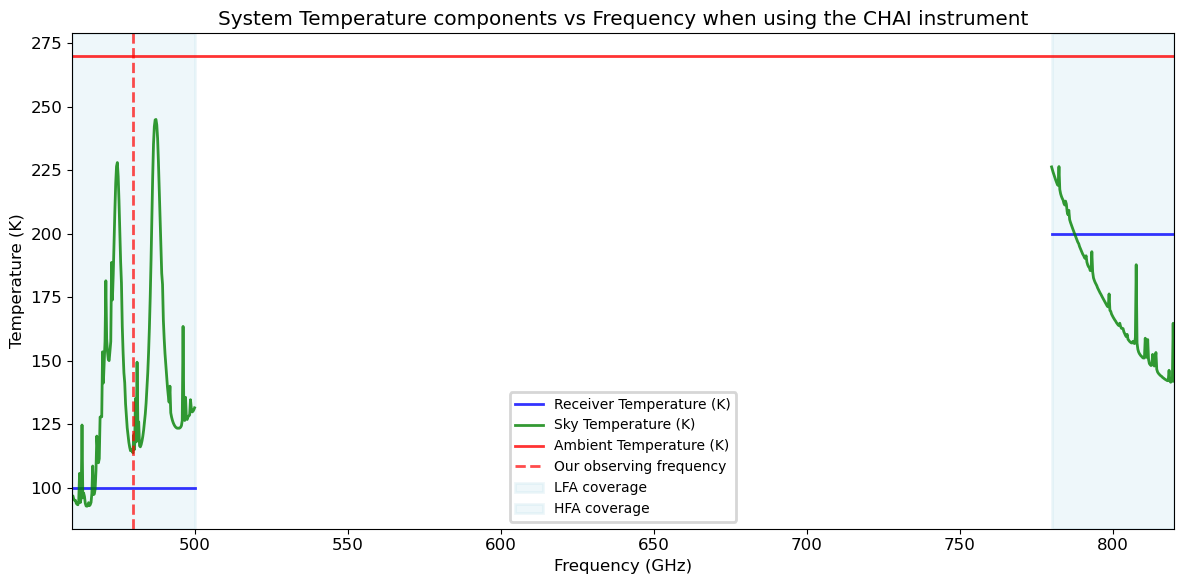

In [32]:
fig, ax = plt.subplots()
ax.plot(freq1, [t.value for t in t_rx_values[:nf]], '-',label = 'Receiver Temperature (K)', color='b', markersize=10, alpha=0.8)
ax.plot(freq2, [t.value for t in t_rx_values[nf:]], '-', color='b', markersize=10, alpha=0.8)
ax.plot(freq1, t_sky_contribution[:nf], '-',label = 'Sky Temperature (K)', color='g', markersize=10, alpha=0.8)
ax.plot(freq2, t_sky_contribution[nf:], '-',color='g', markersize=10, alpha=0.8)
ax.plot(frequencies, t_amb_contribution, '-',label = 'Ambient Temperature (K)', color='r', markersize=10, alpha=0.8)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
ax.axvspan(freq1[0],freq1[-1], color='lightblue', alpha=0.2, label='LFA coverage')
ax.axvspan(freq2[0],freq2[-1], color='lightblue', alpha=0.2, label='HFA coverage')
ax.legend()
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Temperature (K)')
ax.set_title('System Temperature components vs Frequency when using the CHAI instrument')

plt.tight_layout()
plt.show()

## SEFD Calculation

The System Equivalent Flux Density (SEFD) characterises the sensitivity of the telescope system. The system temperature derived in the instrument module is used to calculate the overall SEFD for the telescope, which is then used to calculate the sensitivity.

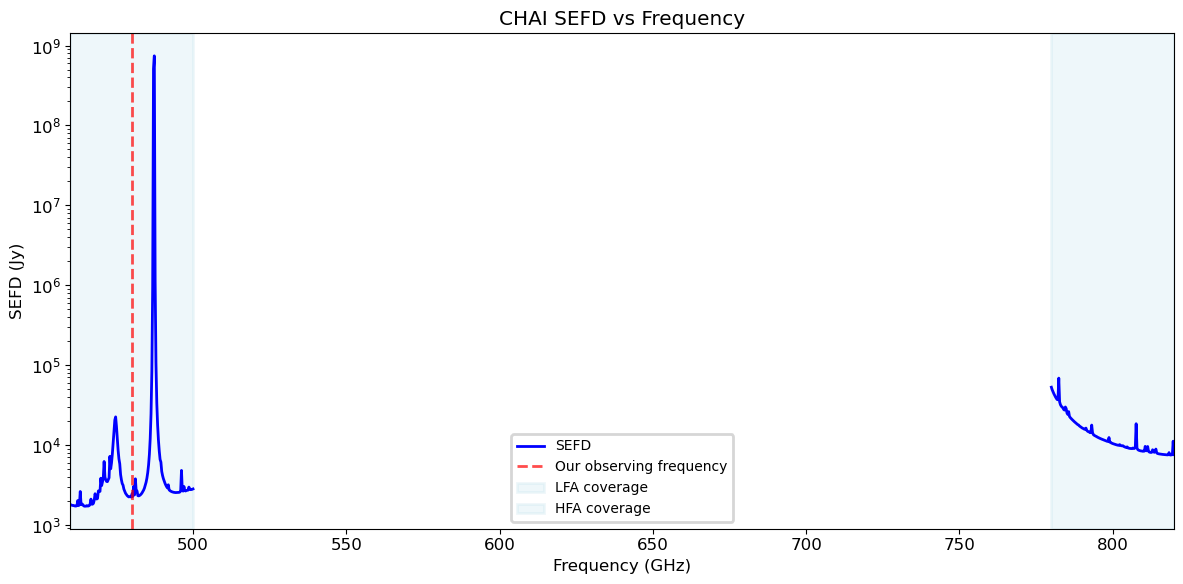

In [33]:
# Plot SEFD as a function of frequency
fig, ax = plt.subplots()
ax.plot(freq1, sefd_values[:nf], 'b-', linewidth=2, label='SEFD')
ax.plot(freq2, sefd_values[nf:], 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
ax.axvspan(freq1[0],freq1[-1], color='lightblue', alpha=0.2, label='LFA coverage')
ax.axvspan(freq2[0],freq2[-1], color='lightblue', alpha=0.2, label='HFA coverage')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('SEFD (Jy)')
ax.set_yscale('log')
ax.set_title('CHAI SEFD vs Frequency')

ax.legend()
plt.tight_layout()
plt.show()



## Sensitivity Calculation

With all of those underlying values calculated and plotted, now let's calculate the RMS sensitivity of the telescope when using the CHAI instrument.

Sensitivity for an integration time of 30.0 min


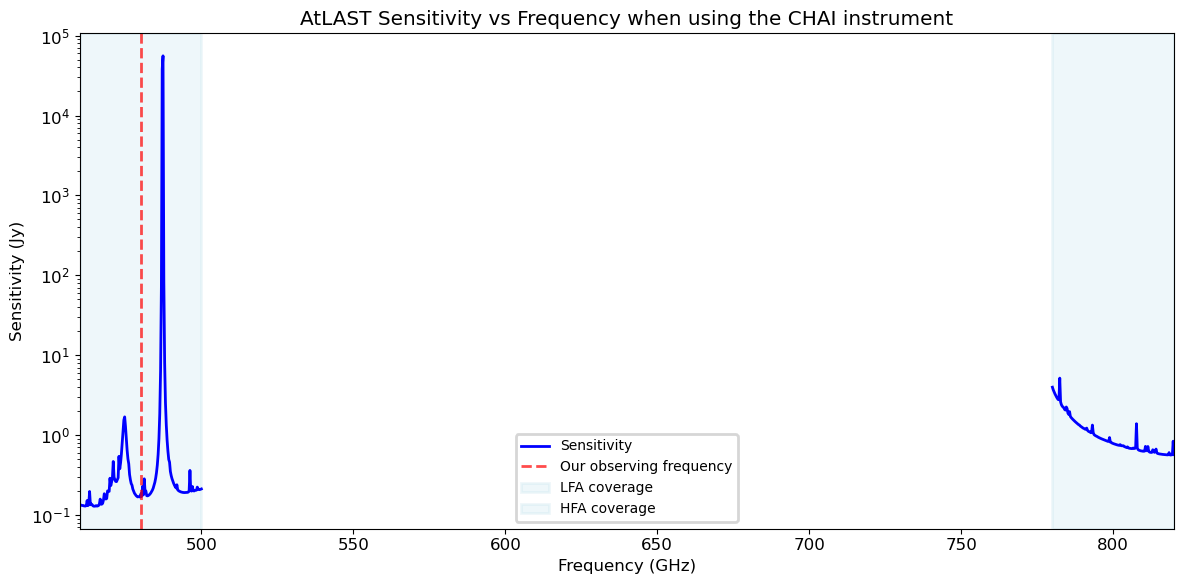

In [34]:
# Remind ourselves of the integration time used for this calculation
print(f"Sensitivity for an integration time of {calculator.user_input.t_int}")

# Show calculated sensitivity
fig, ax = plt.subplots()
# extract the astropy quantity sensitivities from the sensitivity array calculated above
ax.plot(freq1, [q.to("Jy").value for q in sensitivity[:nf]], 'b-', linewidth=2, label='Sensitivity')
ax.plot(freq2, [q.to("Jy").value for q in sensitivity[nf:]], 'b-', linewidth=2)

# label the plot
ax.axvline(calculator.user_input.obs_freq.value, color='r', linestyle='--', alpha=0.7, label='Our observing frequency')
ax.axvspan(freq1[0],freq1[-1], color='lightblue', alpha=0.2, label='LFA coverage')
ax.axvspan(freq2[0],freq2[-1], color='lightblue', alpha=0.2, label='HFA coverage')
ax.set_yscale('log')
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Sensitivity (Jy)')
ax.set_title('AtLAST Sensitivity vs Frequency when using the CHAI instrument')

ax.legend()
plt.tight_layout()
plt.show()


## Summary

This notebook has demonstrated the key capabilities of the AtLAST Sensitivity Calculator for the CHAI instrument:

1. **Instrument Selection**: Verified automatic selection and demonstrated explicit instrument setting
2. **Frequency Coverage**: Explored CHAI's 460-820 GHz range
3. **Atmospheric Effects**: Analysed transmission and emission across the CHAIr operating frequency ranges
4. **System Performance**: Calculated system temperature, its components, and the overall SEFD
5. **Sensitivity Predictions**: Evaluated spectral line sensitivities across the CHAI frequency range

